In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch==2.3.1+cu121 torchvision==0.18.1+cu121 torchaudio==2.3.1 --extra-index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.0/781.0 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 96.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 86.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 101.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric \-f https://data.pyg.org/whl/torch-2.3.1+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.3.1+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 92.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.4/950.4 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch, torch_geometric
import torch_scatter, torch_sparse
print("Torch:", torch.__version__)
print("PyG:", torch_geometric.__version__)


Torch: 2.3.1+cu121
PyG: 2.6.1


In [6]:
pip install -q rdkit-pypi 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 63.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
# =========================
# Full end-to-end GNN pipeline for single parquet shard (graph-level targets)
# =========================

import os
import math
import random
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool

from rdkit import Chem
from rdkit.Chem import rdchem

# -------------------------
# Cleanup Kaggle working folder
# -------------------------
WORK_DIR = "/kaggle/working"
for f in os.listdir(WORK_DIR):
    path = os.path.join(WORK_DIR, f)
    if os.path.isfile(path):
        os.remove(path)
    elif os.path.isdir(path):
        shutil.rmtree(path)

# -------------------------
# Paths
# -------------------------
PARQUET_PATH = "/kaggle/input/polyone-aa-parquet/polyOne_aa (1).parquet"
OUTPUT_PT = "/kaggle/working/polyone_single.pt"
NORM_STATS_PATH = "/kaggle/working/target_norm_stats.npz"

# -------------------------
# Atom & bond features
# -------------------------
def atom_features(atom: rdchem.Atom):
    return [
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetTotalValence(),
        int(atom.GetIsAromatic())
    ]

def bond_features(bond: rdchem.Bond):
    bt = bond.GetBondType()
    bt_onehot = [
        int(bt == rdchem.BondType.SINGLE),
        int(bt == rdchem.BondType.DOUBLE),
        int(bt == rdchem.BondType.TRIPLE),
        int(bt == rdchem.BondType.AROMATIC),
    ]
    return bt_onehot + [int(bond.GetIsConjugated()), int(bond.IsInRing())]

# -------------------------
# Load parquet
# -------------------------
print("Loading parquet...")
df = pd.read_parquet(PARQUET_PATH)
print("Columns:", df.columns.tolist())
print("Rows:", len(df))

# Detect SMILES column
smiles_cols = [c for c in df.columns if c.lower() == "smiles"]
if len(smiles_cols) == 0:
    candidates = [c for c in df.columns if "smile" in c.lower()]
    if len(candidates) == 0:
        raise RuntimeError("Couldn't find SMILES column.")
    smiles_col = candidates[0]
else:
    smiles_col = smiles_cols[0]
print("Using SMILES column:", smiles_col)

# Targets = all other columns
target_cols = [c for c in df.columns if c != smiles_col]
print(f"Found {len(target_cols)} target columns")

# -------------------------
# Normalize targets
# -------------------------
props_df = df[target_cols].copy()
props = props_df.to_numpy(dtype=np.float32)
props = np.nan_to_num(props, nan=0.0)

# Compute mean and std per target
target_means = props.mean(axis=0)
target_stds = props.std(axis=0) + 1e-8  # avoid division by zero
props_norm = (props - target_means) / target_stds

# Save normalization stats for later denormalization
np.savez(NORM_STATS_PATH, mean=target_means, std=target_stds)
print("Saved target normalization stats to", NORM_STATS_PATH)

# -------------------------
# Convert rows -> graph-level Data
# -------------------------
def smiles_to_data_row(smiles, y_row):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    x_list = [atom_features(a) for a in mol.GetAtoms()]
    x = torch.tensor(x_list, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_index.append([i,j])
        edge_index.append([j,i])
        edge_attr.append(bf)
        edge_attr.append(bf)
    if len(edge_index)==0:
        edge_index = torch.empty((2,0), dtype=torch.long)
        edge_attr = torch.empty((0,6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GRAPH-LEVEL y (normalized)
    y_tensor = torch.tensor(y_row, dtype=torch.float)  # one row per graph

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_tensor)

print("Converting rows to graphs...")
data_list = []
smiles_series = df[smiles_col].astype(str).tolist()

for i in tqdm(range(len(df))):
    g = smiles_to_data_row(smiles_series[i], props_norm[i])
    if g is not None:
        data_list.append(g)

print("Converted samples:", len(data_list))
torch.save(data_list, OUTPUT_PT)
print("Saved processed dataset to", OUTPUT_PT)


Loading parquet...
Columns: ['smiles', 'Egc', 'Egb', 'Eib', 'CED', 'Ei', 'Eea', 'nc', 'ne', 'epse_6.0', 'epsc', 'epse_3.0', 'epse_1.78', 'epse_15.0', 'epse_4.0', 'epse_5.0', 'epse_2.0', 'epse_9.0', 'epse_7.0', 'TSb', 'TSy', 'epsb', 'YM', 'permCH4', 'permCO2', 'permH2', 'permO2', 'permN2', 'permHe', 'Eat', 'rho', 'LOI', 'Xc', 'Xe', 'Cp', 'Td', 'Tg', 'Tm']
Rows: 500000
Using SMILES column: smiles
Found 37 target columns
Saved target normalization stats to /kaggle/working/target_norm_stats.npz
Converting rows to graphs...


100%|██████████| 500000/500000 [10:14<00:00, 813.51it/s]


Converted samples: 500000
Saved processed dataset to /kaggle/working/polyone_single.pt


Dataset size: 500000 Num targets: 37
Splits -> train: 400000 val: 50000 test: 50000
Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 001 | TrainLoss: 7.4926 | ValRMSE: 1.7029 | ValMAE: 0.8263 | ValR2: -1.9388


Epoch 002 | TrainLoss: 4.8097 | ValRMSE: 1.8392 | ValMAE: 0.8089 | ValR2: -2.4319


Epoch 003 | TrainLoss: 4.1407 | ValRMSE: 1.6479 | ValMAE: 0.6991 | ValR2: -1.7596


...

Epoch 027 | TrainLoss: 2.3125 | ValRMSE: 0.9287 | ValMAE: 0.4259 | ValR2: 0.1262


Epoch 028 | TrainLoss: 2.2287 | ValRMSE: 0.6380 | ValMAE: 0.3599 | ValR2: 0.5906


Epoch 029 | TrainLoss: 2.2142 | ValRMSE: 0.6097 | ValMAE: 0.3481 | ValR2: 0.6259


Epoch 030 | TrainLoss: 2.2113 | ValRMSE: 0.6152 | ValMAE: 0.3427 | ValR2: 0.6191


Test RMSE: 0.6167 | Test MAE: 0.3482 | Test R2: 0.6276
Per-task MAE (first 20 tasks): [0.2607327  0.2541368  0.263928   0.38933983 0.34459025 0.26115513
 0.2152442  0.21648453 0.24871303 0.2458379  0.25534028 0.24792211
 0.22704324 0.252542   0.2506107  0.24650571 0.23762181 0.2444512
 0.4351715  0.46451303]


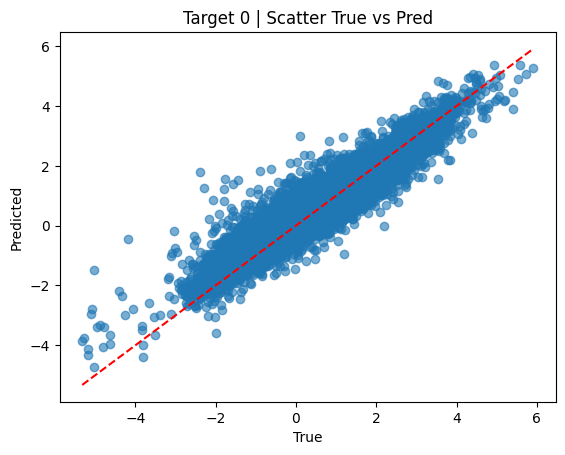

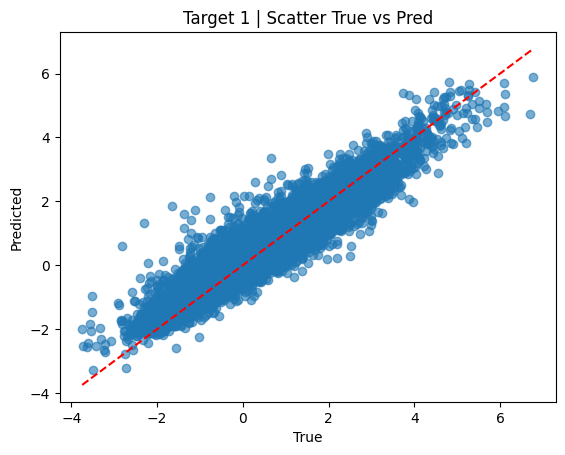

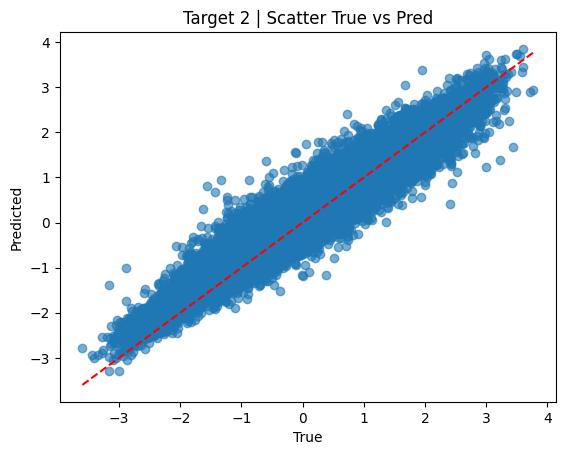

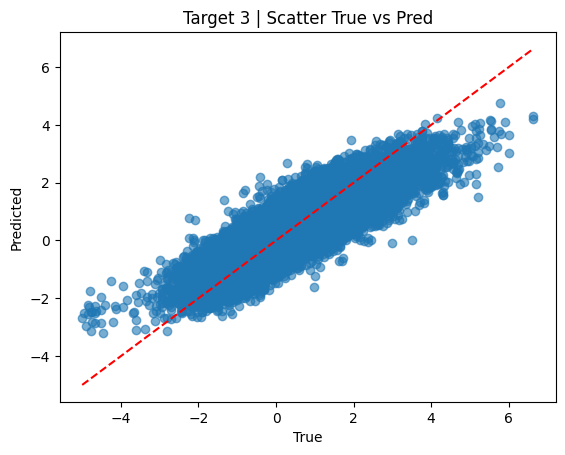

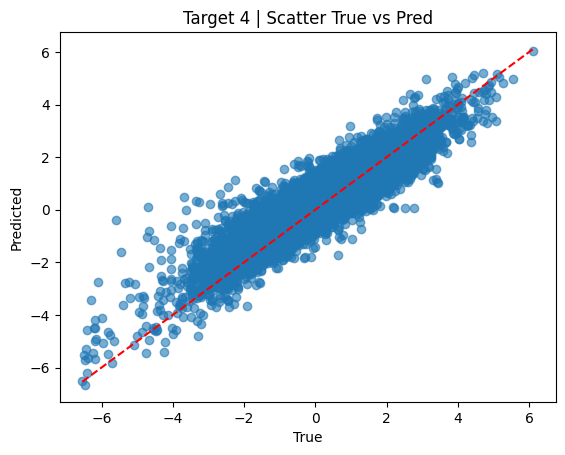

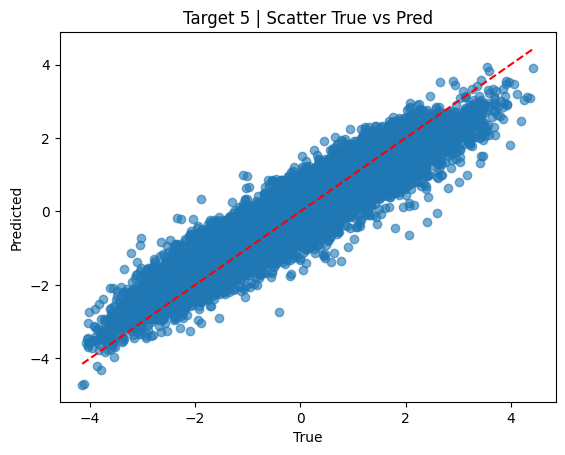

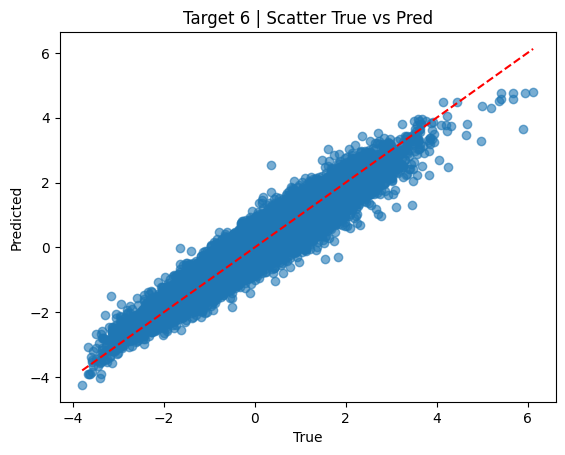

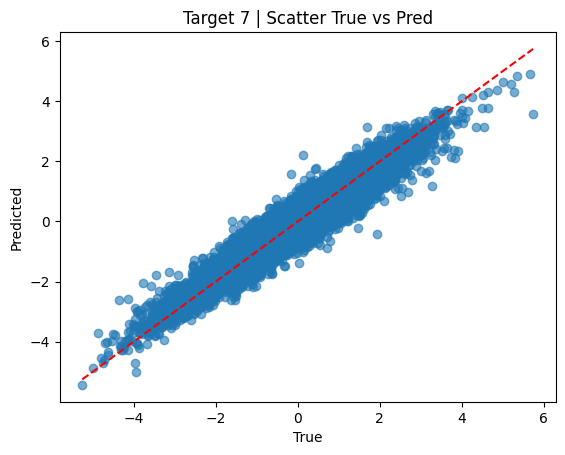

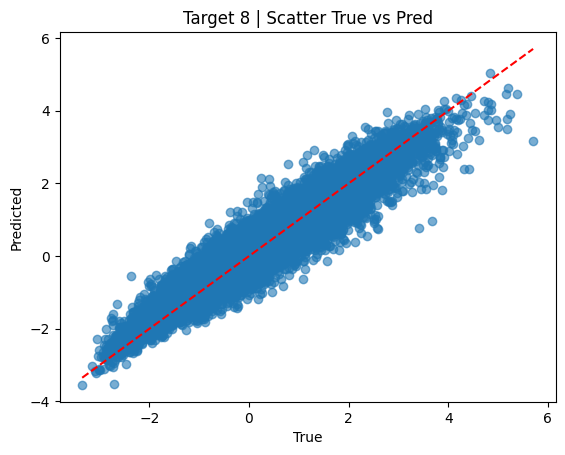

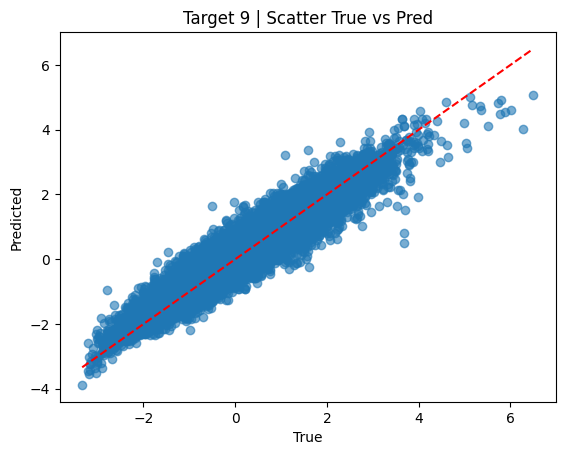

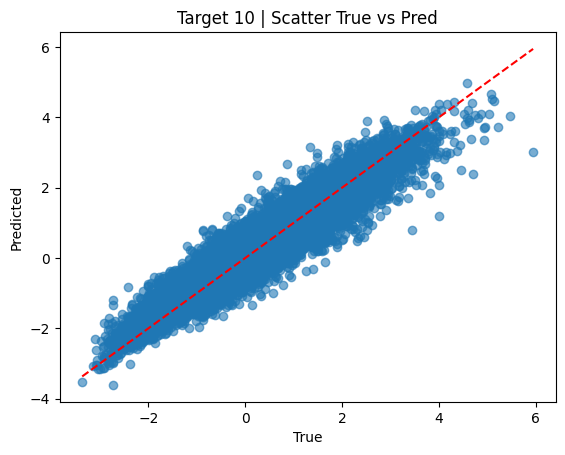

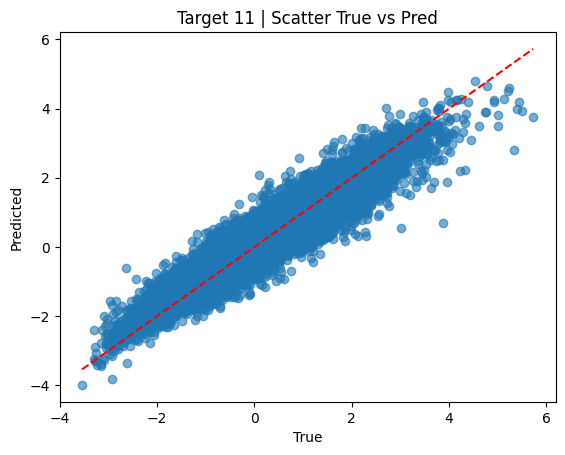

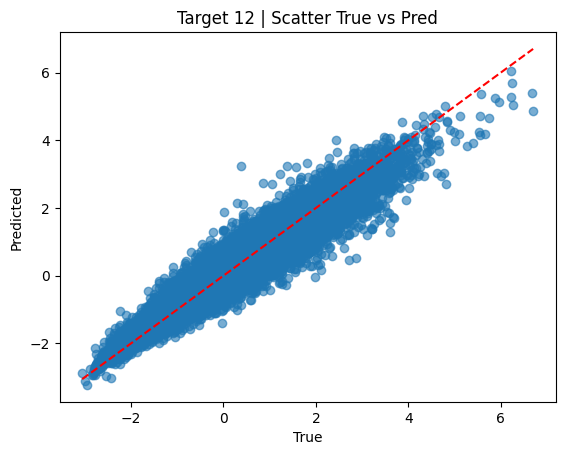

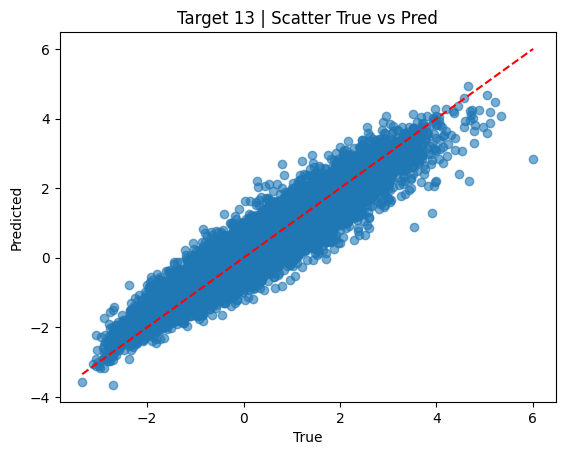

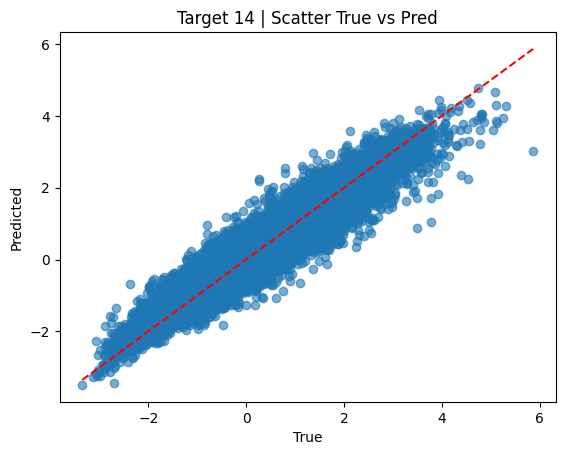

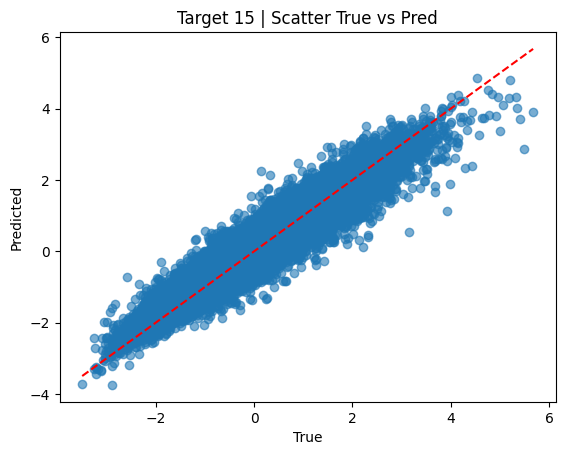

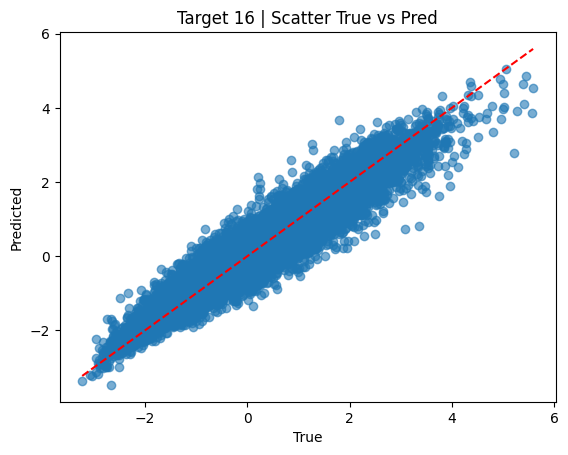

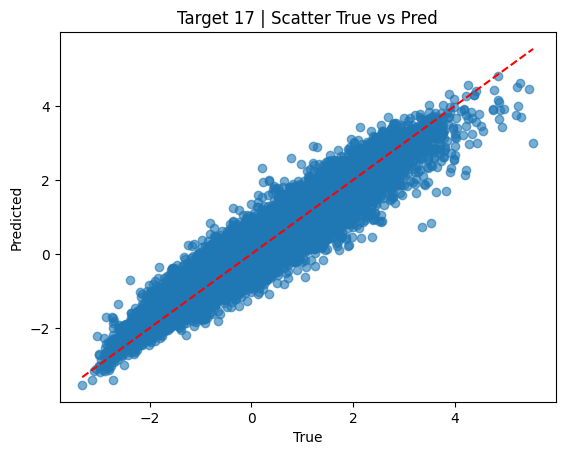

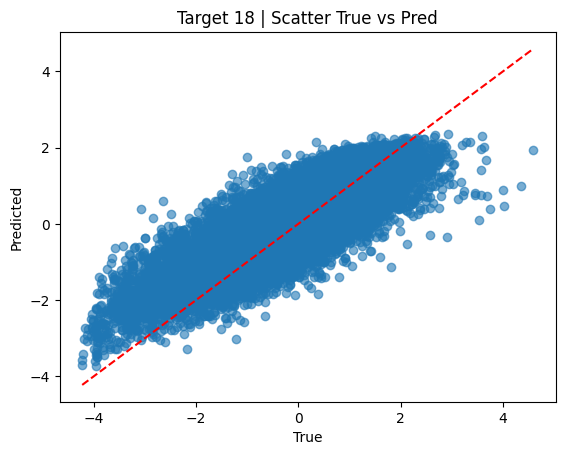

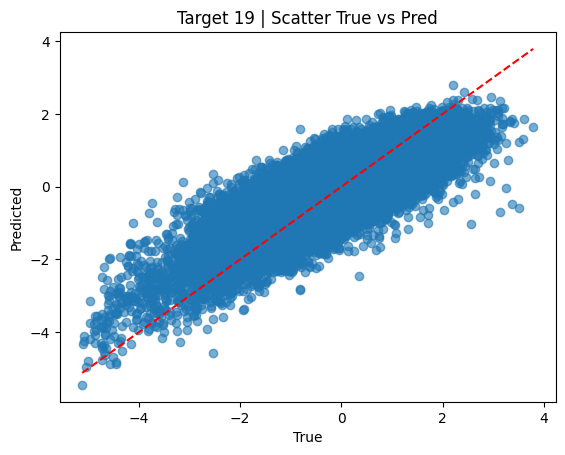

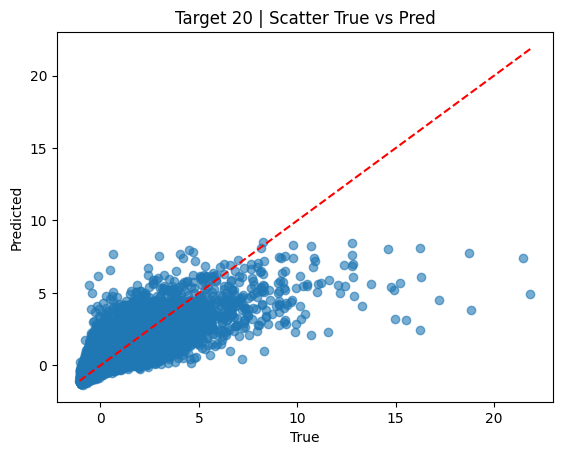

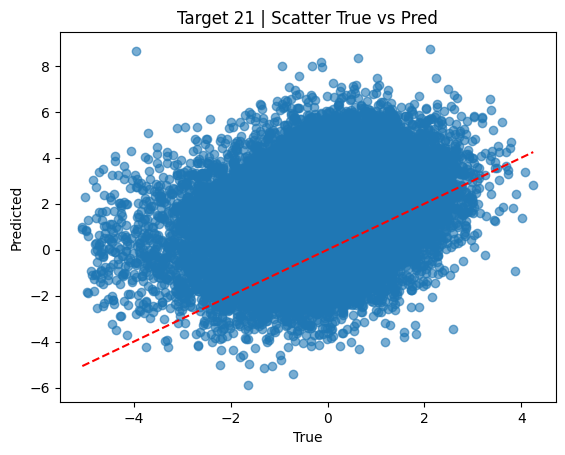

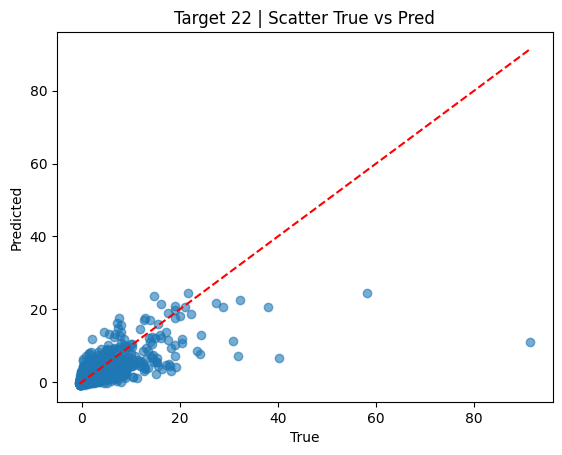

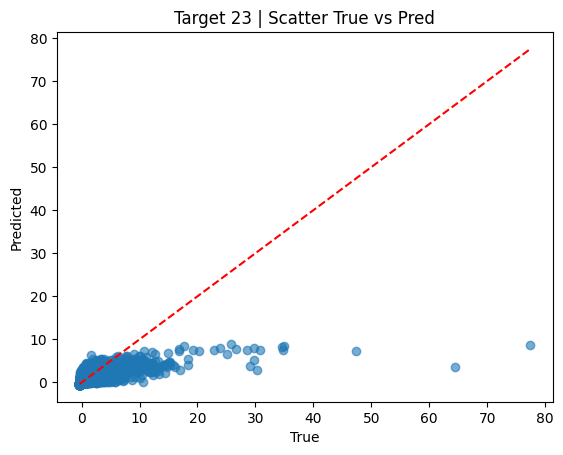

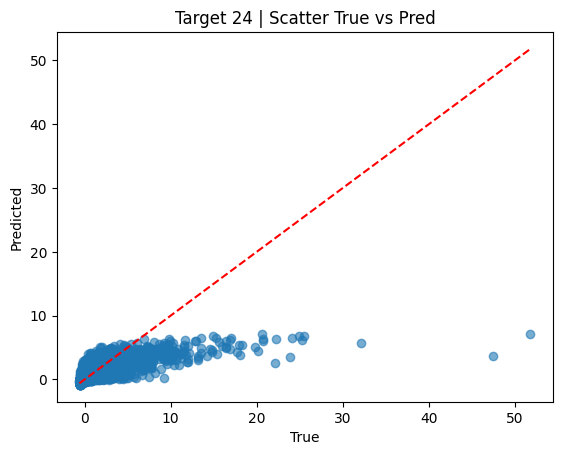

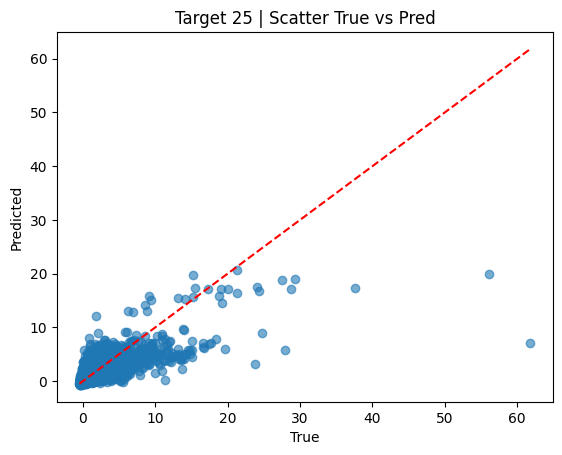

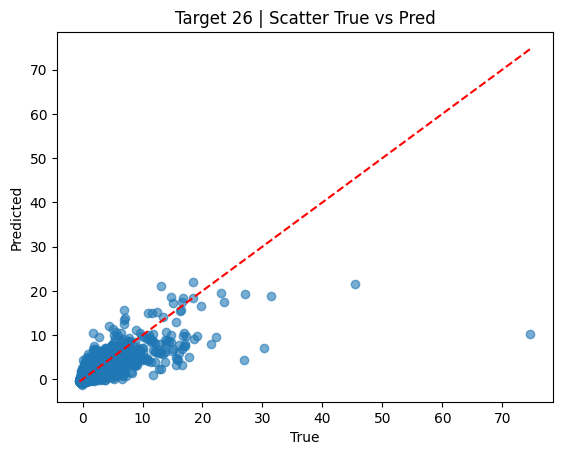

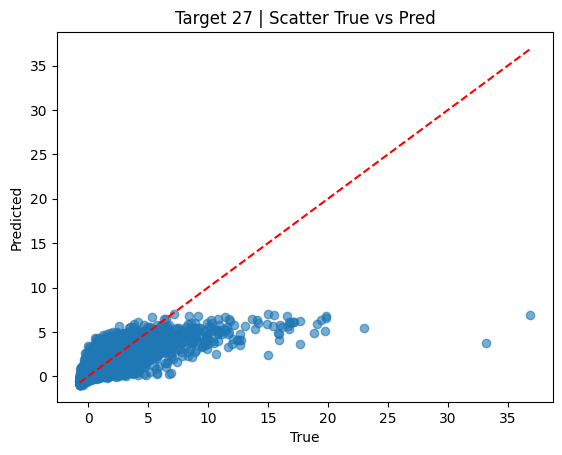

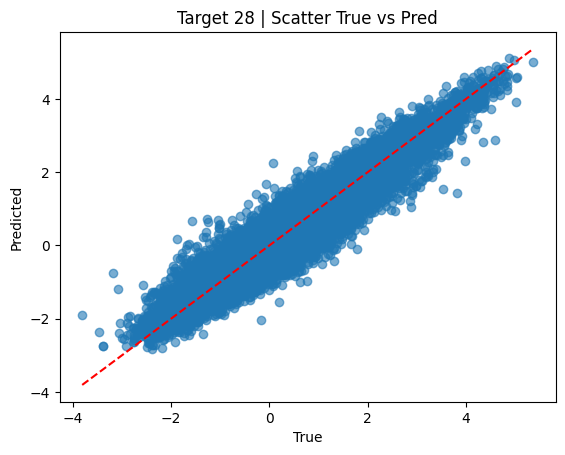

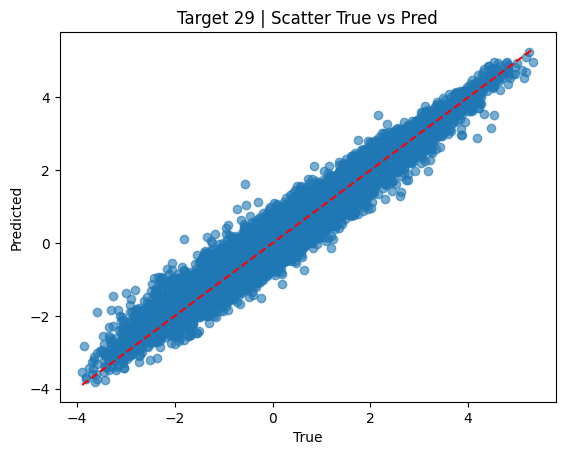

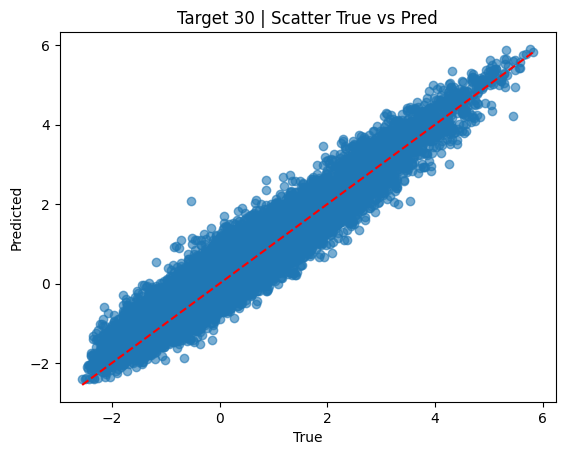

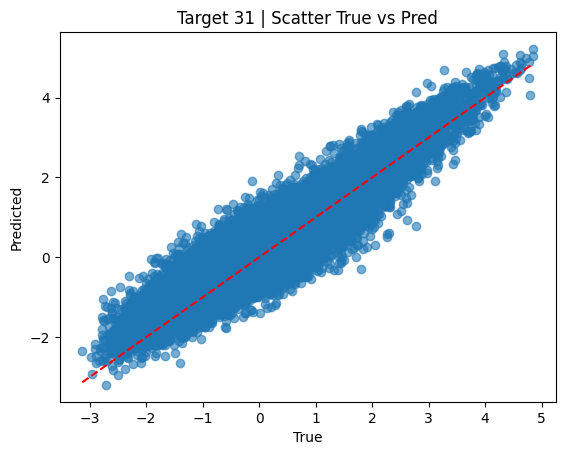

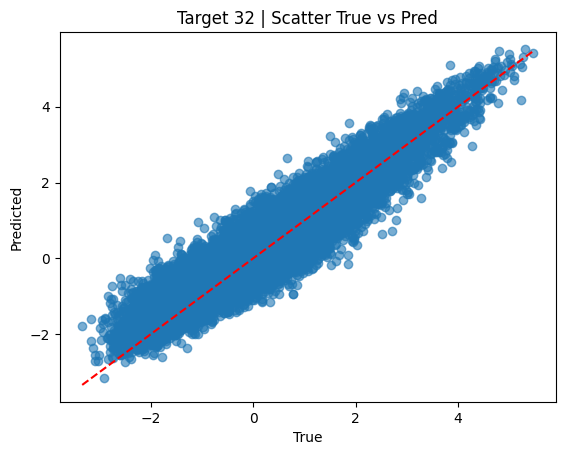

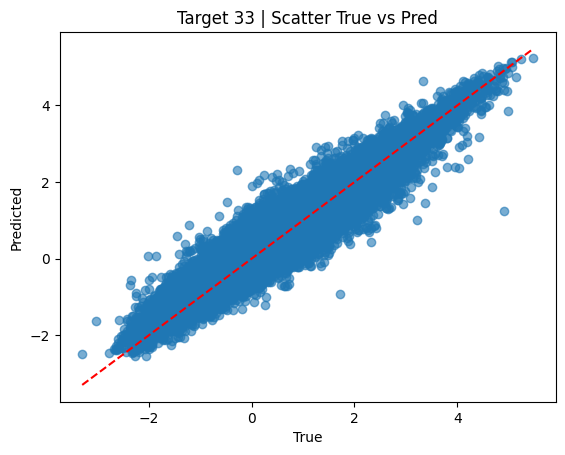

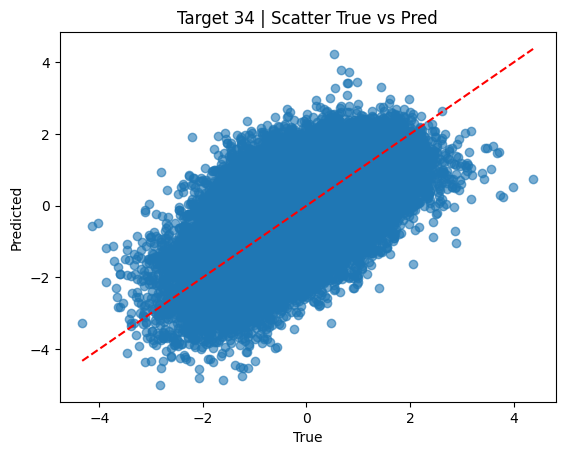

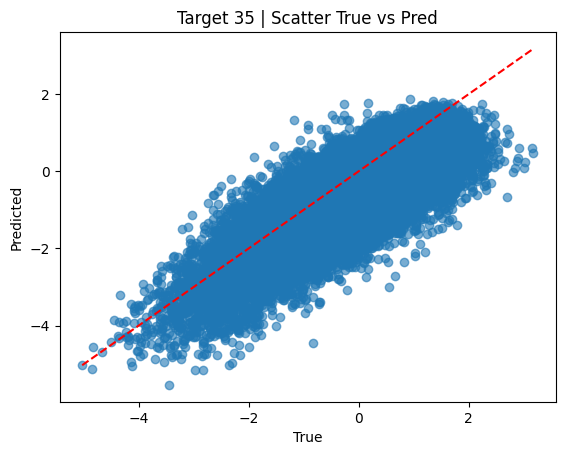

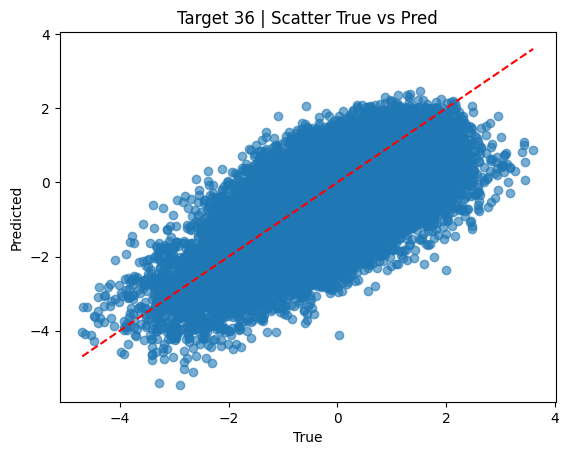

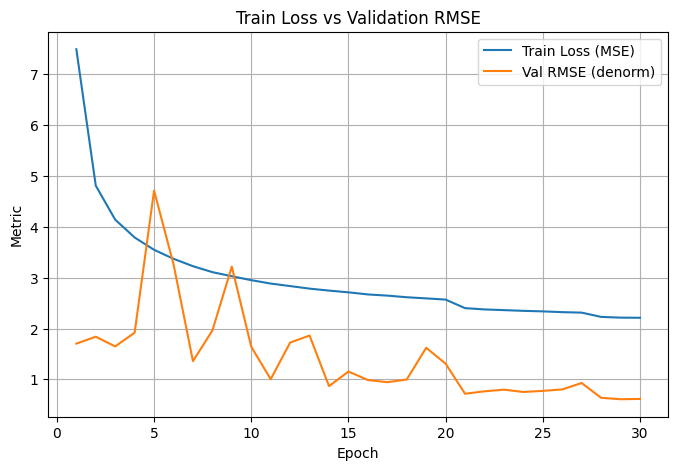

In [8]:
from tqdm import tqdm  # Progress bars
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import InMemoryDataset, DataLoader
from torch_geometric.nn import GINConv, global_add_pool
import matplotlib.pyplot as plt

# =========================
# Dataset wrapper
# =========================
class SimpleInMemoryDataset(InMemoryDataset):
    def __init__(self, data_list):
        super().__init__(None)
        self.data, self.slices = self.collate(data_list)

dataset = SimpleInMemoryDataset(data_list)
num_targets = len(target_cols)
print("Dataset size:", len(dataset), "Num targets:", num_targets)

# =========================
# Dataset split
# =========================
def split_dataset(dataset, train_frac=0.8, val_frac=0.1, seed=42):
    n = len(dataset)
    indices = list(range(n))
    random.Random(seed).shuffle(indices)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train+n_val]
    test_idx = indices[n_train+n_val:]
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = split_dataset(dataset)
train_set = SimpleInMemoryDataset([dataset[i] for i in train_idx])
val_set   = SimpleInMemoryDataset([dataset[i] for i in val_idx])
test_set  = SimpleInMemoryDataset([dataset[i] for i in test_idx])
print("Splits -> train:", len(train_set), "val:", len(val_set), "test:", len(test_set))

# =========================
# GIN model
# =========================
class GINMultiTask(nn.Module):
    def __init__(self, in_channels, hidden_dim=128, num_layers=3, num_tasks=1, dropout=0.1):
        super().__init__()
        self.num_tasks = num_tasks
        self.hidden_dim = hidden_dim
        nn1 = nn.Sequential(nn.Linear(in_channels, hidden_dim),
                            nn.ReLU(),
                            nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINConv(nn1)
        self.convs = nn.ModuleList()
        for _ in range(num_layers-1):
            mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                nn.ReLU(),
                                nn.Linear(hidden_dim, hidden_dim))
            self.convs.append(GINConv(mlp))
        self.bn = nn.ModuleList([nn.BatchNorm1d(hidden_dim) for _ in range(num_layers)])
        self.dropout = dropout
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_dim, hidden_dim//2),
                          nn.ReLU(),
                          nn.Linear(hidden_dim//2,1))
            for _ in range(num_tasks)
        ])

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.bn[0](x)
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            x = F.relu(x)
            x = self.bn[i+1](x)

        batch = data.batch if hasattr(data, "batch") else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        g = global_add_pool(x, batch)  # [num_graphs, hidden_dim]

        # -------------------------
        # Normalize per graph after pooling
        # -------------------------
        g_mean = g.mean(dim=1, keepdim=True)
        g_std  = g.std(dim=1, keepdim=True) + 1e-6  # avoid divide by zero
        g_norm = (g - g_mean) / g_std

        g_norm = F.dropout(g_norm, p=self.dropout, training=self.training)
        outs = [head(g_norm).view(-1) for head in self.heads]
        out = torch.stack(outs, dim=1)
        return out

# =========================
# Training utilities
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

in_channels = dataset[0].x.shape[1]
model = GINMultiTask(in_channels=in_channels, hidden_dim=128, num_layers=3,
                     num_tasks=num_targets, dropout=0.1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, verbose=True)

# Load normalization stats for final denormalization
NORM_STATS_PATH = "/kaggle/working/target_norm_stats.npz"
norm_stats = np.load(NORM_STATS_PATH)
target_means = torch.tensor(norm_stats['mean'], dtype=torch.float, device=device)
target_stds  = torch.tensor(norm_stats['std'], dtype=torch.float, device=device)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=64, shuffle=False)

# =========================
# Evaluation function (denormalized)
# =========================
def evaluate(loader, model):
    model.eval()
    y_true_list, y_pred_list = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            batch = batch.to(device)
            pred = model(batch)
            pred_denorm = pred * target_stds + target_means
            target_denorm = batch.y.view(batch.num_graphs, -1)
            y_true_list.append(target_denorm.cpu())
            y_pred_list.append(pred_denorm.cpu())
    y_true = torch.cat(y_true_list, dim=0).numpy()
    y_pred = torch.cat(y_pred_list, dim=0).numpy()

    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    per_task_mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    return per_task_mae, mae, rmse, r2, y_true, y_pred

# =========================
# Training loop with tqdm
# =========================
best_val_rmse = float("inf")
patience = 20
pat_cnt = 0
num_epochs = 30
train_losses, val_rmse_list = [], []

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - Training", leave=False):
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        # Normalize per graph after pooling done inside model
        target_norm = (batch.y.view(batch.num_graphs, -1) - target_means.unsqueeze(0)) / target_stds.unsqueeze(0)
        loss = F.mse_loss(pred, target_norm)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch.num_graphs
    running_loss /= len(train_set)
    train_losses.append(running_loss)

    # Validation (denormalized metrics)
    model.eval()
    y_true_list, y_pred_list = [], []
    for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - Validation", leave=False):
        batch = batch.to(device)
        pred = model(batch)
        pred_denorm = pred * target_stds + target_means
        target_denorm = batch.y.view(batch.num_graphs, -1)
        y_true_list.append(target_denorm.cpu())
        y_pred_list.append(pred_denorm.cpu())

    y_pred_val = torch.cat(y_pred_list, dim=0).detach().cpu().numpy()
    y_true_val = torch.cat(y_true_list, dim=0).detach().cpu().numpy()


    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    val_rmse = math.sqrt(mean_squared_error(y_true_val, y_pred_val))
    agg_mae_val = mean_absolute_error(y_true_val, y_pred_val)
    val_r2 = r2_score(y_true_val, y_pred_val)
    val_rmse_list.append(val_rmse)

    scheduler.step(val_rmse)

    print(f"Epoch {epoch:03d} | TrainLoss: {running_loss:.4f} | "
          f"ValRMSE: {val_rmse:.4f} | ValMAE: {agg_mae_val:.4f} | ValR2: {val_r2:.4f}")

    # Early stopping
    if val_rmse < best_val_rmse - 1e-2:
        best_val_rmse = val_rmse
        pat_cnt = 0
        torch.save(model.state_dict(), "/kaggle/working/best_gnn.pth")
    else:
        pat_cnt += 1
        if pat_cnt >= patience:
            print("Early stopping triggered.")
            break

# =========================
# Final evaluation (denormalized)
# =========================
model.load_state_dict(torch.load("/kaggle/working/best_gnn.pth", map_location=device))
per_task_mae_test, agg_mae_test, test_rmse, test_r2, y_true, y_pred = evaluate(test_loader, model)
print(f"Test RMSE: {test_rmse:.4f} | Test MAE: {agg_mae_test:.4f} | Test R2: {test_r2:.4f}")
print("Per-task MAE (first 20 tasks):", per_task_mae_test[:20])

# =========================
# Plots
# =========================
# True vs predicted
for i in range(num_targets):
    plt.figure()
    plt.scatter(y_true[:,i], y_pred[:,i], alpha=0.6)
    plt.plot([y_true[:,i].min(), y_true[:,i].max()], [y_true[:,i].min(), y_true[:,i].max()], 'r--')
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Target {i} | Scatter True vs Pred")
    plt.show()

# Train / Validation curves
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss (MSE)')
plt.plot(range(1, len(val_rmse_list)+1), val_rmse_list, label='Val RMSE (denorm)')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Train Loss vs Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()
